In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
df=pd.read_csv(r'E:\archive\supply_chain_data.csv')
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [35]:
df.shape

(100, 24)

In [36]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [37]:
df
df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [38]:
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [39]:

df['Shipping carriers']=df['Shipping carriers'].str.replace('Carrier',' ',regex=False)
df['Supplier name']=df['Supplier name'].str.replace('Supplier',' ',regex=False)
df['Routes']=df['Routes'].str.replace('Route',' ',regex=False)
df['SKU']=df['SKU'].str.replace('SKU',' ',regex=False)
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,B,187.752075
1,skincare,1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,B,503.065579
2,haircare,2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,C,141.920282
3,skincare,3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,A,254.776159
4,skincare,4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,A,778.864241
96,cosmetics,96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,A,188.742141
97,haircare,97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,A,540.132423
98,skincare,98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,A,882.198864


In [40]:
df = df.drop(['SKU','Supplier name','Routes'], axis=1)

In [41]:
df

,Product type,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,...,Shipping costs,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Costs
0,haircare,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,...,2.956572,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,187.752075
1,skincare,14.843523,95,736,7460.900065,Female,53,30,37,2,...,9.716575,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,503.065579
2,haircare,11.319683,34,8,9577.749626,Unknown,1,10,88,2,...,8.054479,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,141.920282
3,skincare,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,...,1.729569,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,254.776159
4,skincare,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,...,3.890548,Delhi,5,414,3,92.065161,Fail,3.145580,Air,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,77.903927,65,672,7386.363944,Unknown,15,14,26,9,...,8.630339,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,778.864241
96,cosmetics,24.423131,29,324,7698.424766,Non-binary,67,2,32,3,...,5.352878,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,188.742141
97,haircare,3.526111,56,62,4370.916580,Male,46,19,4,9,...,7.904846,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,540.132423
98,skincare,19.754605,43,913,8525.952560,Female,53,1,27,7,...,1.409801,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,882.198864


In [42]:
print(df.columns)


Index(['Product type', 'Price', 'Availability', 'Number of products sold',
       'Revenue generated', 'Customer demographics', 'Stock levels',
       'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers',
       'Shipping costs', 'Location', 'Lead time', 'Production volumes',
       'Manufacturing lead time', 'Manufacturing costs', 'Inspection results',
       'Defect rates', 'Transportation modes', 'Costs'],
      dtype='object')


C:\Users\RAJARSHEE\AppData\Local\Temp\ipykernel_29188\2807402243.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,6))


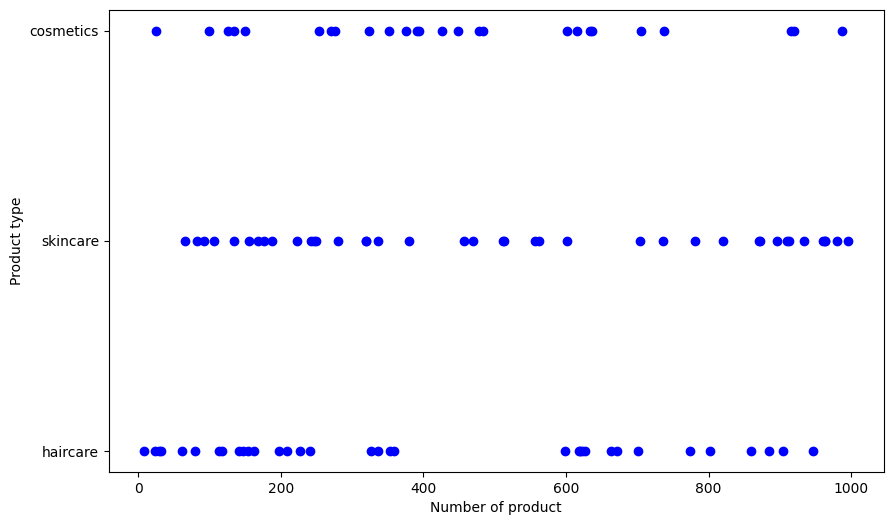

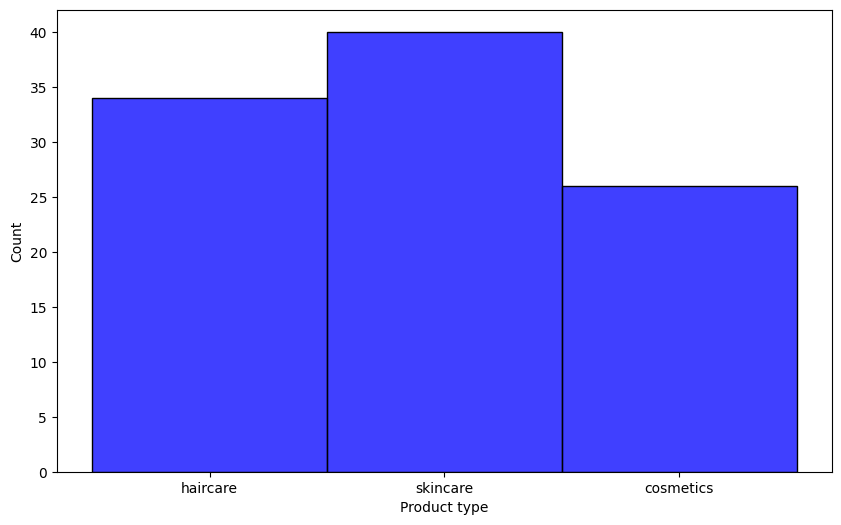

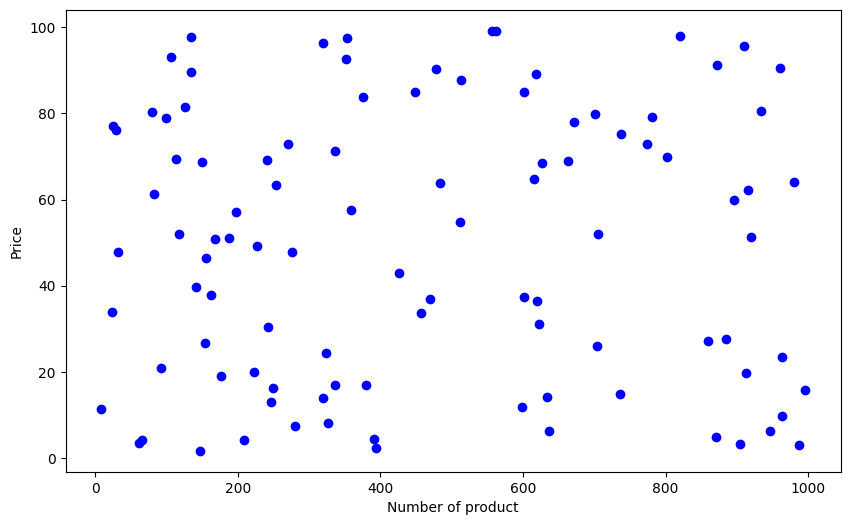

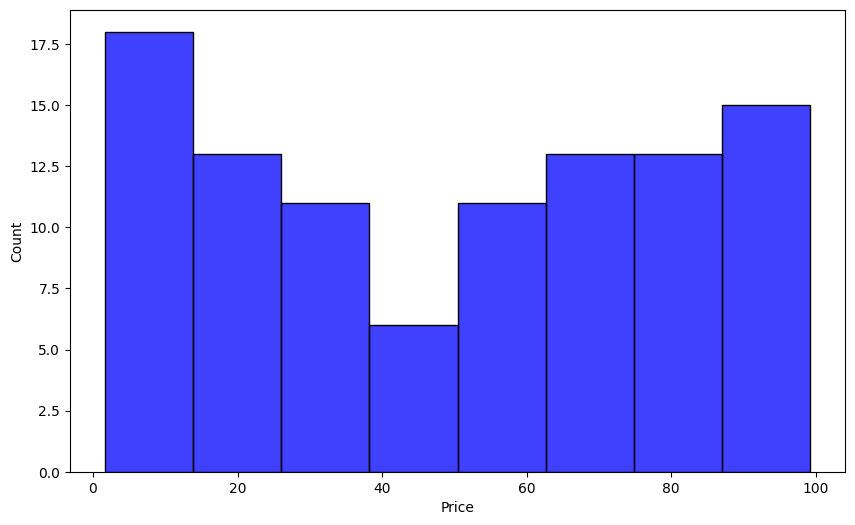

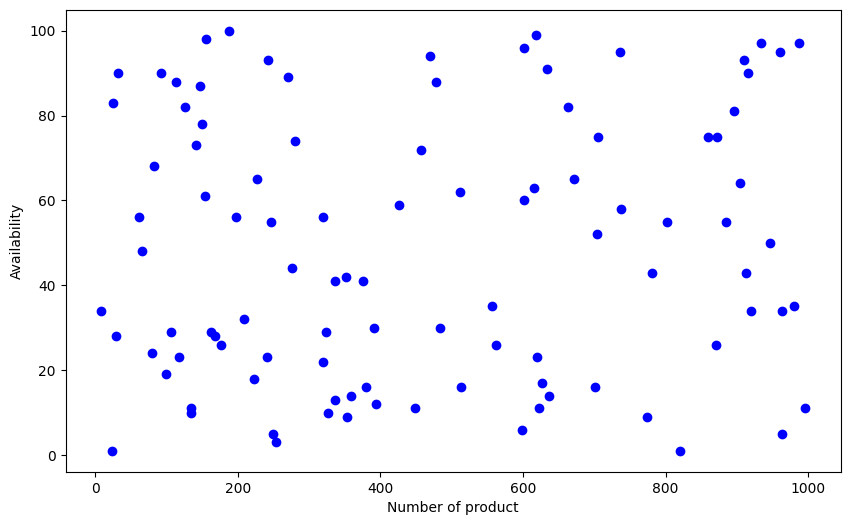

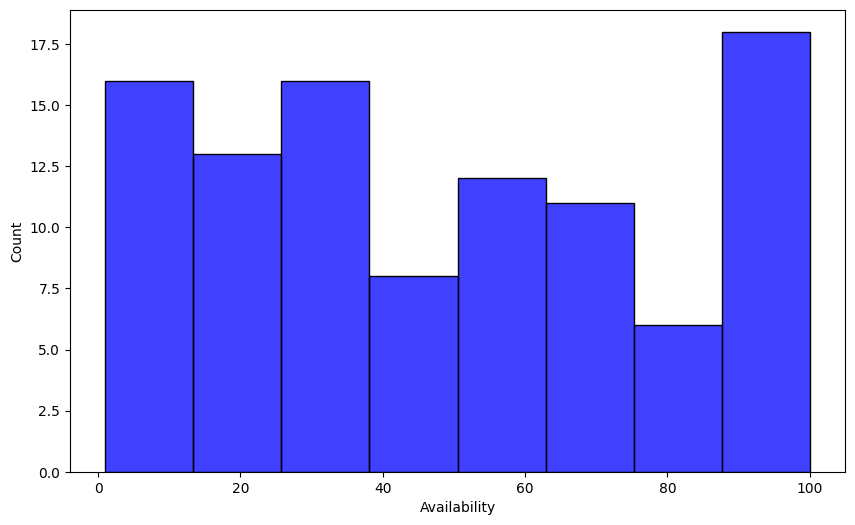

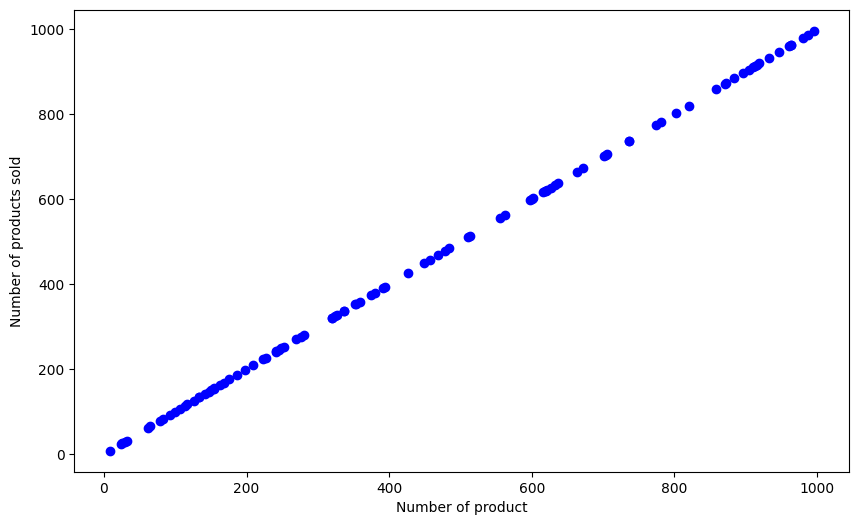

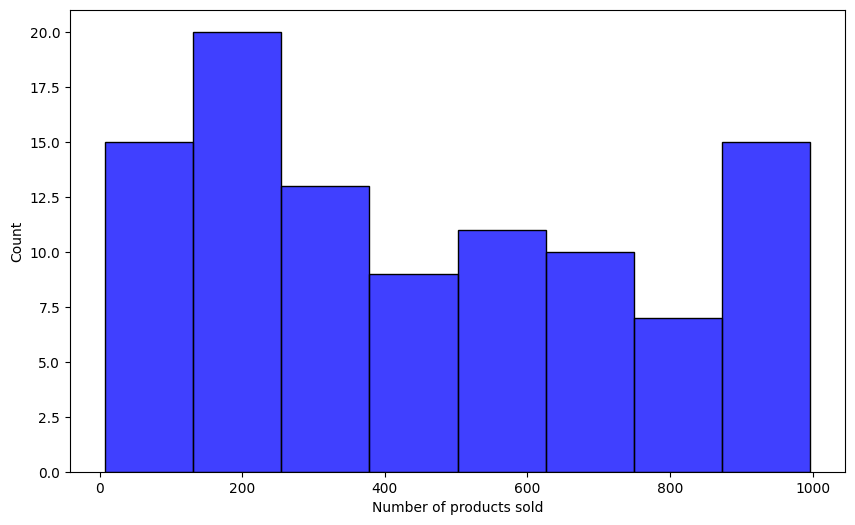

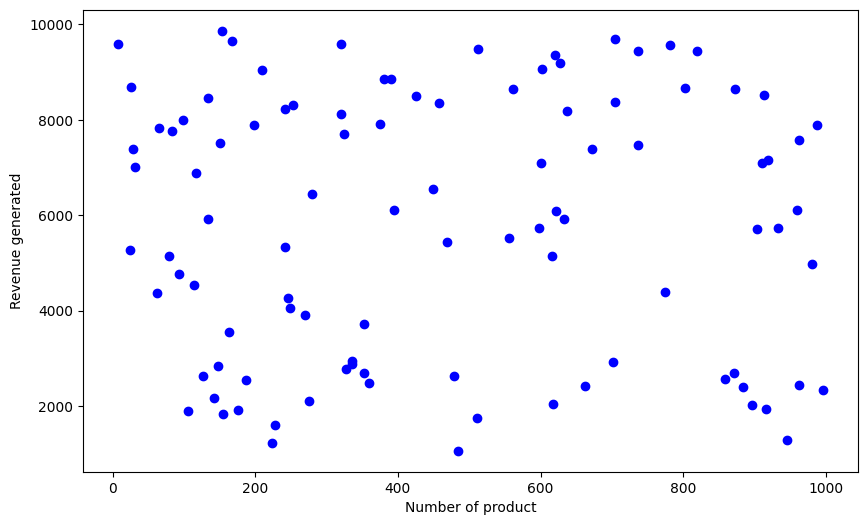

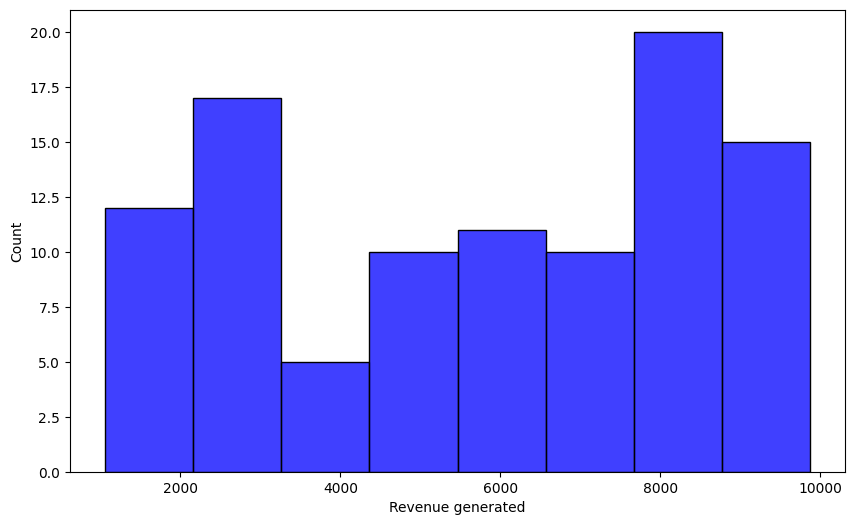

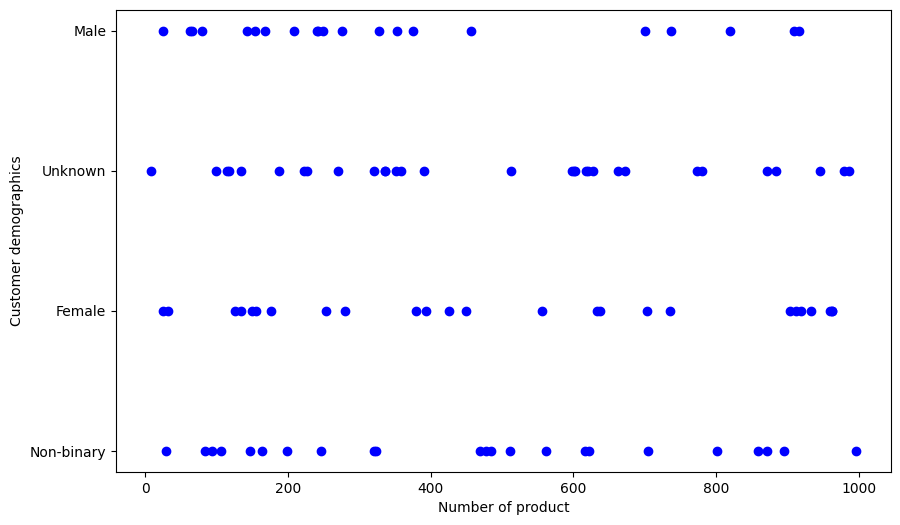

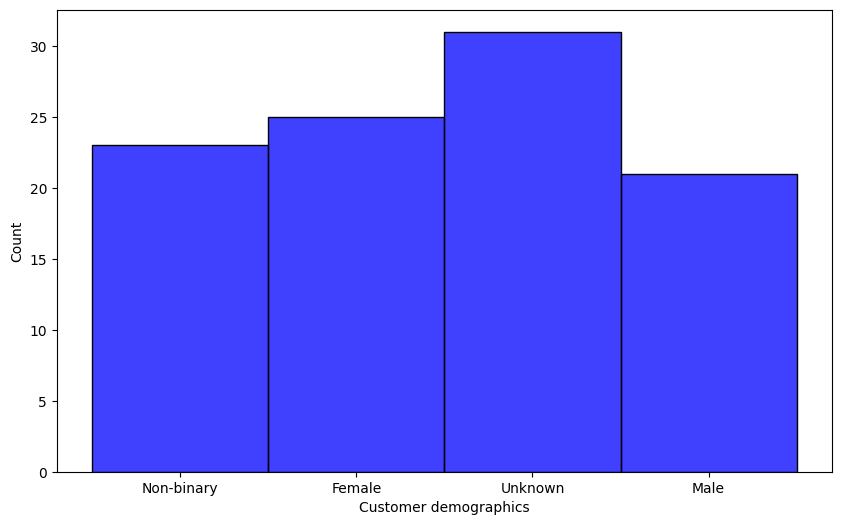

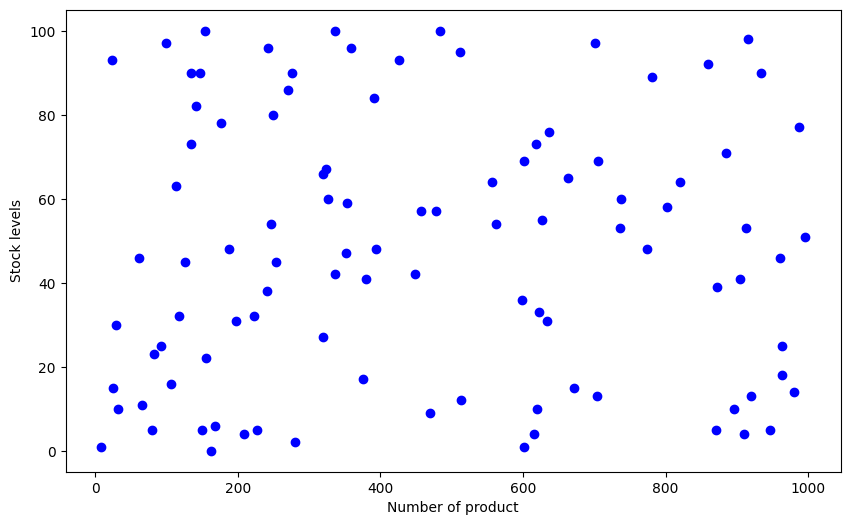

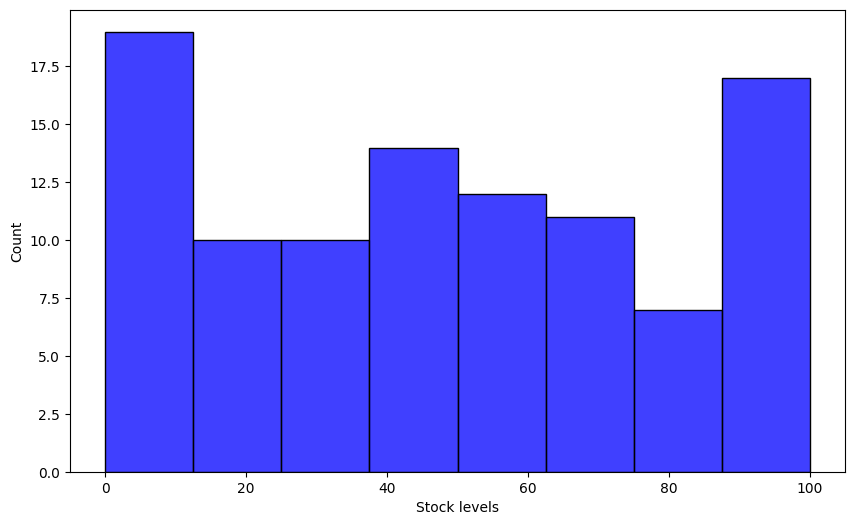

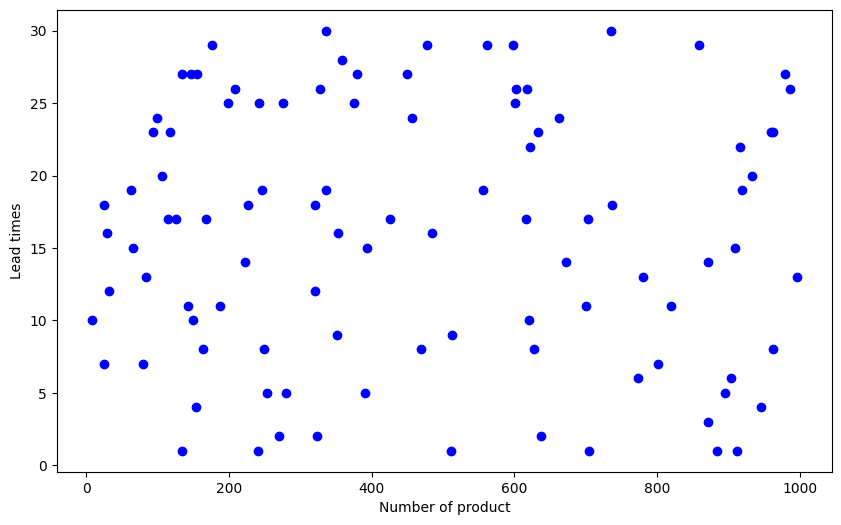

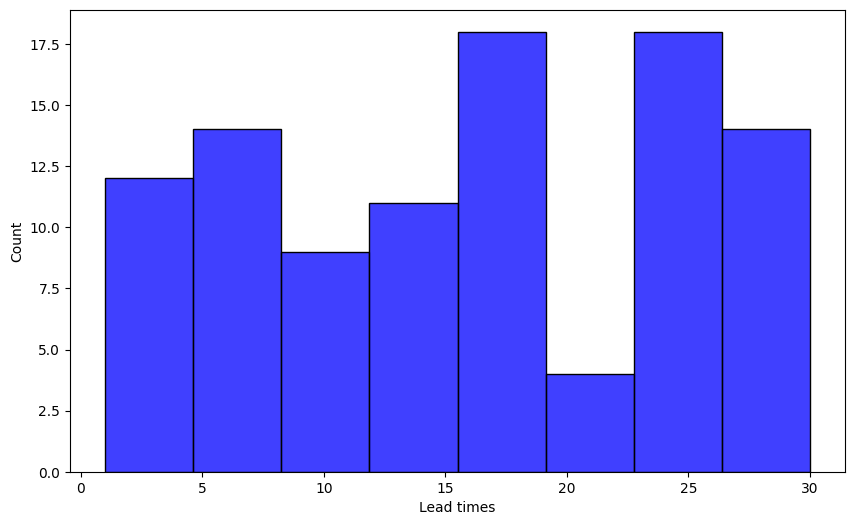

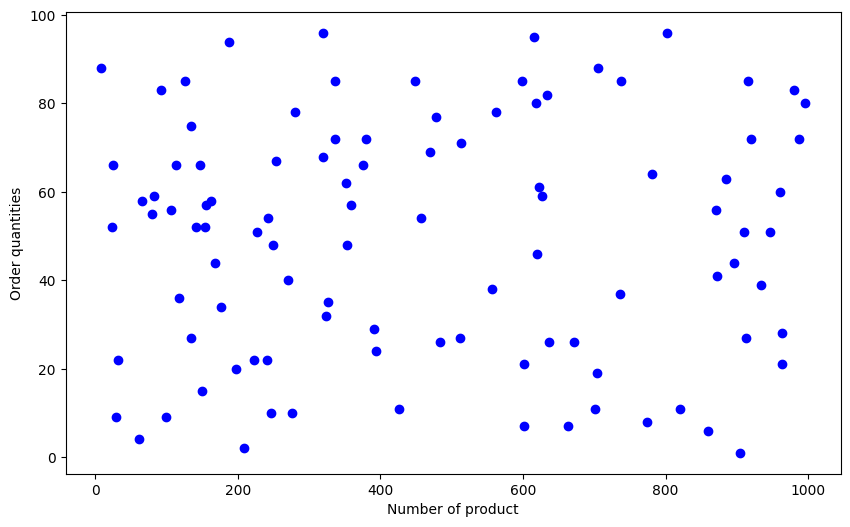

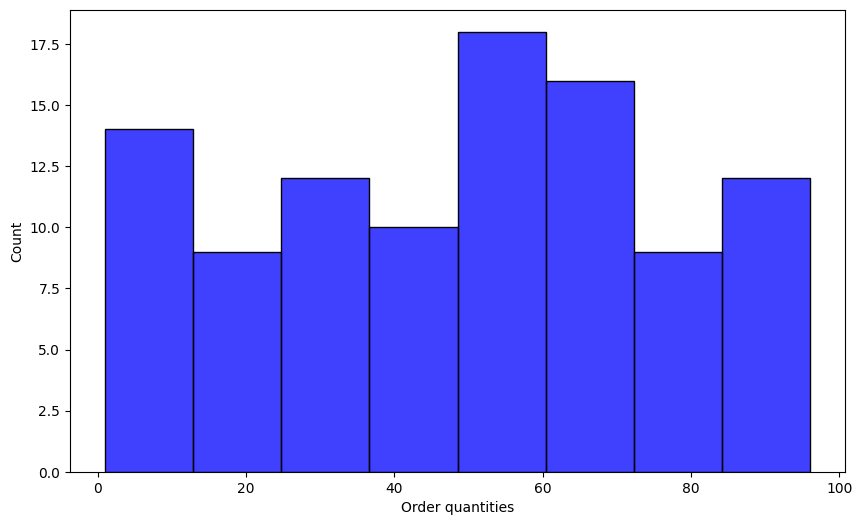

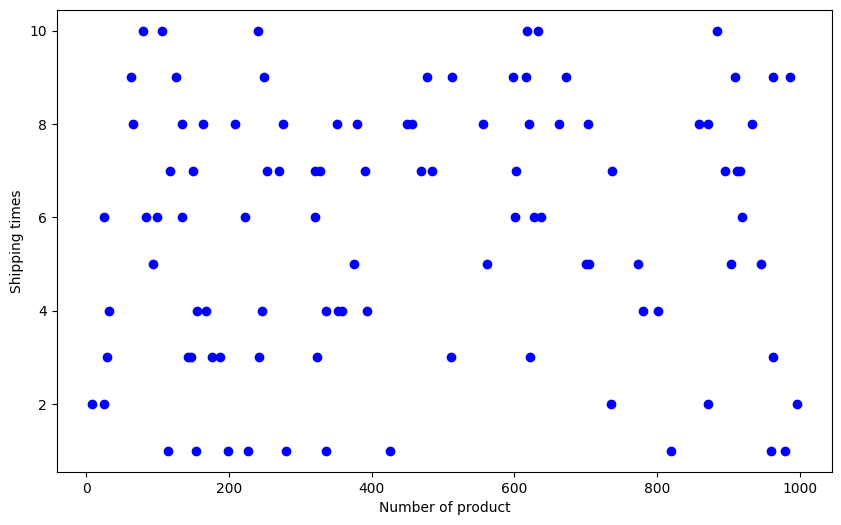

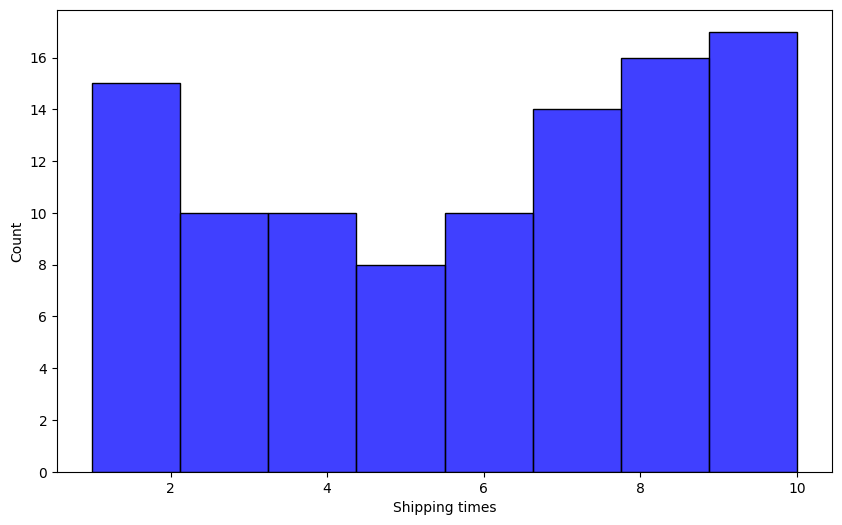

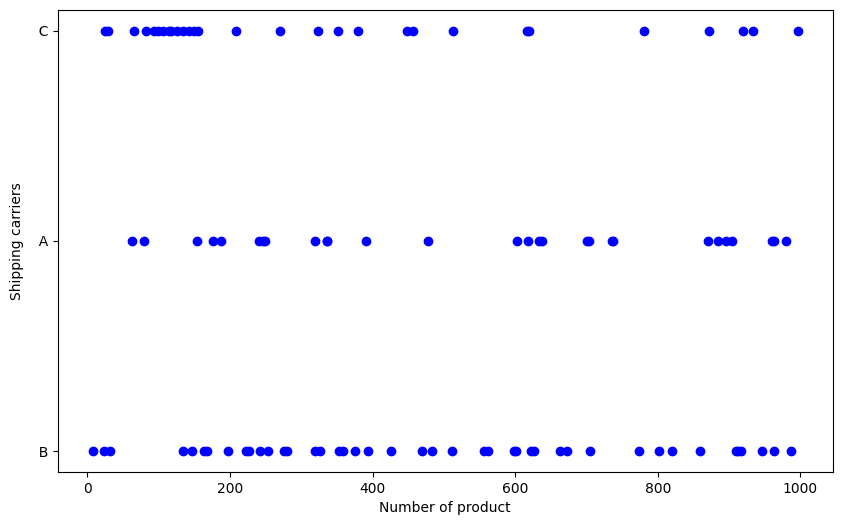

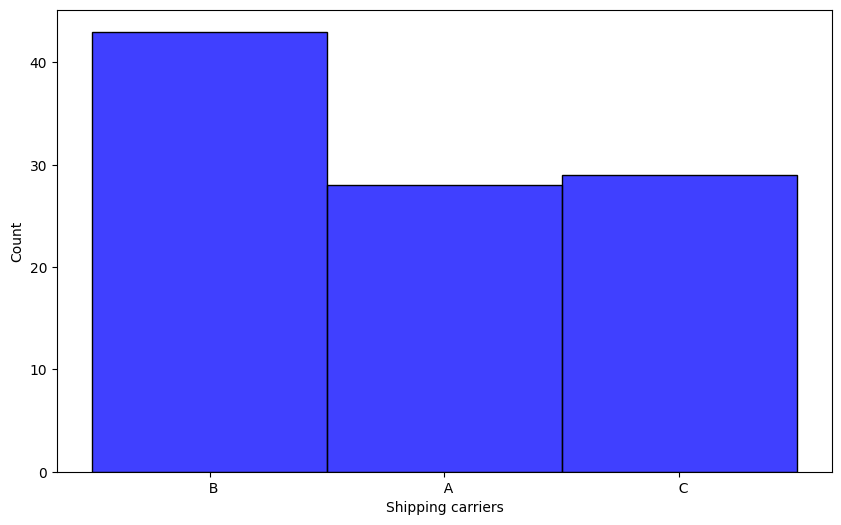

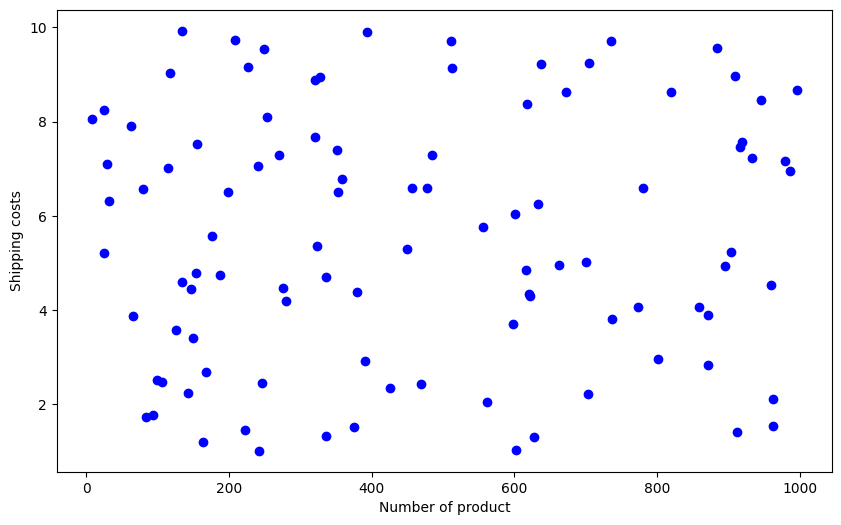

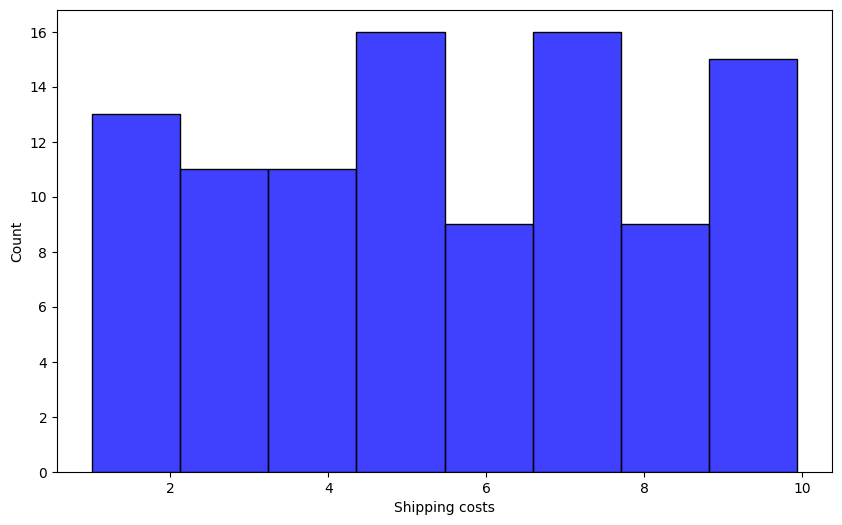

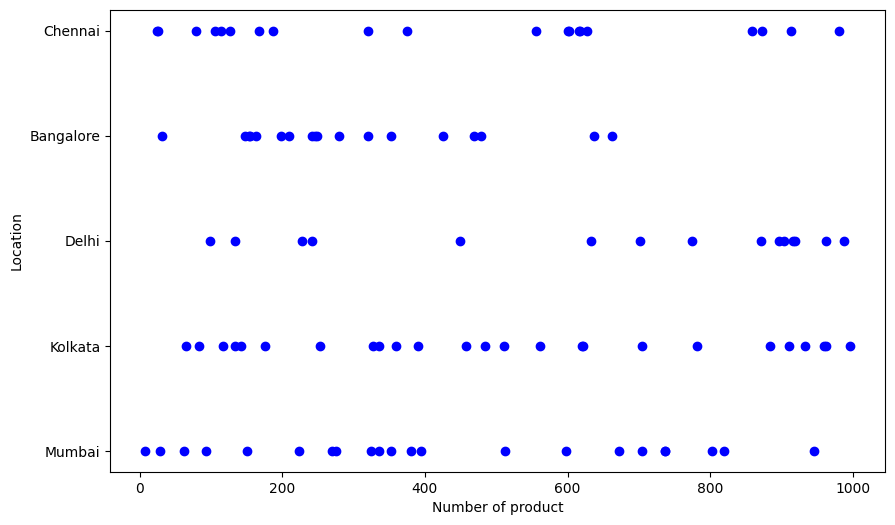

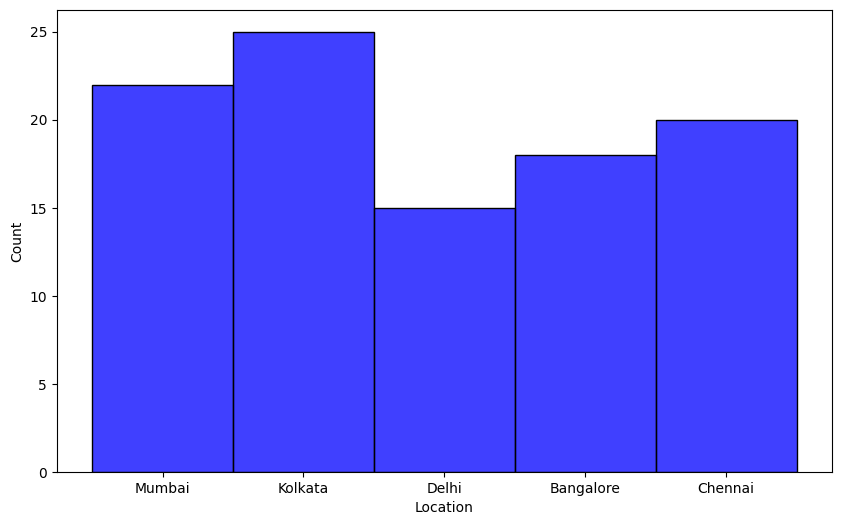

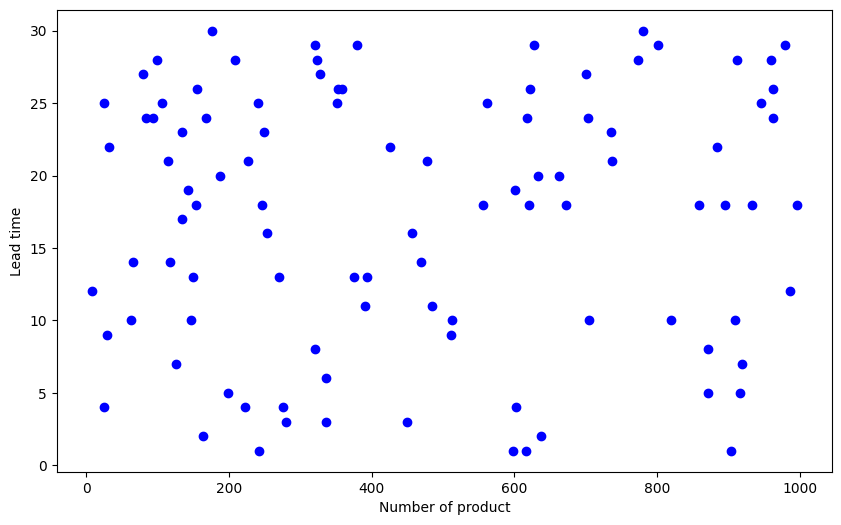

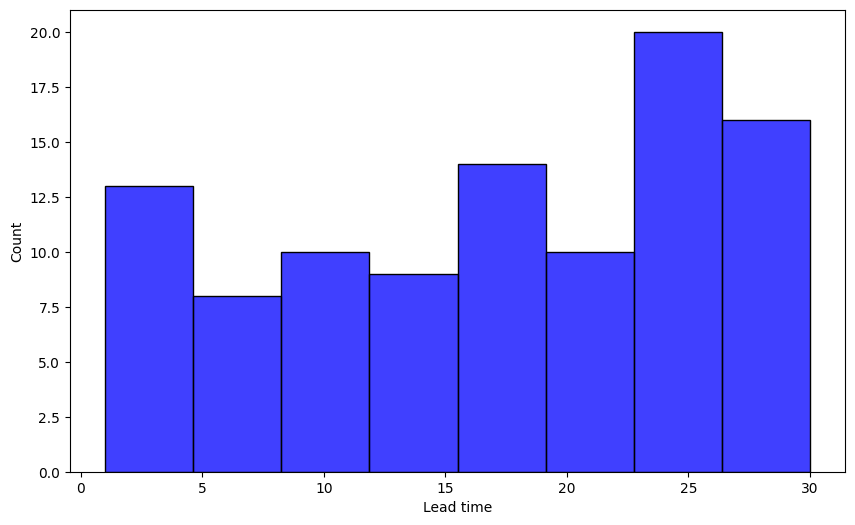

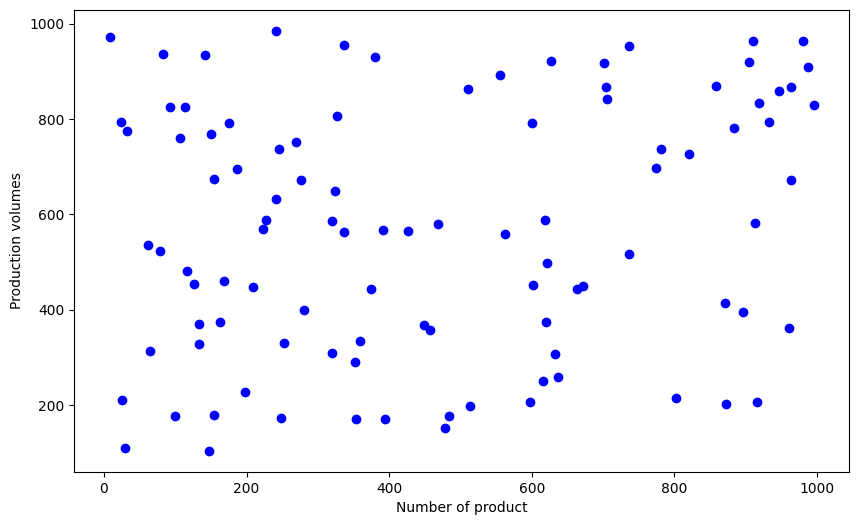

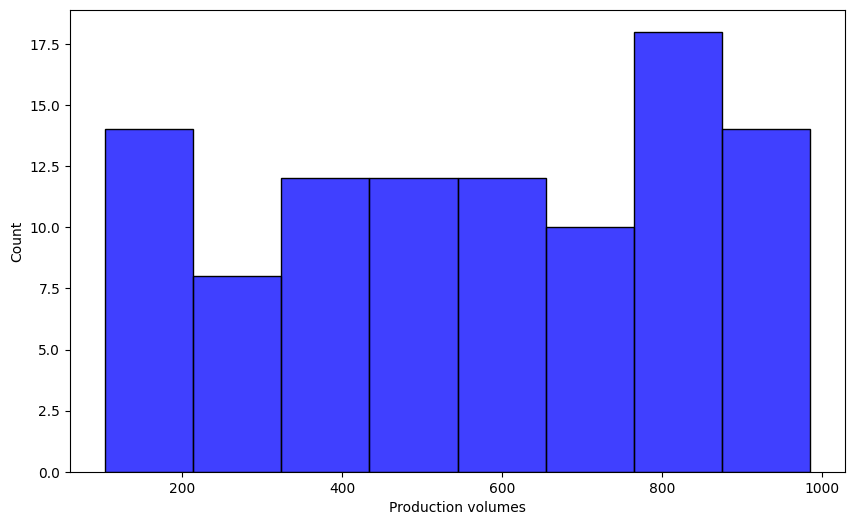

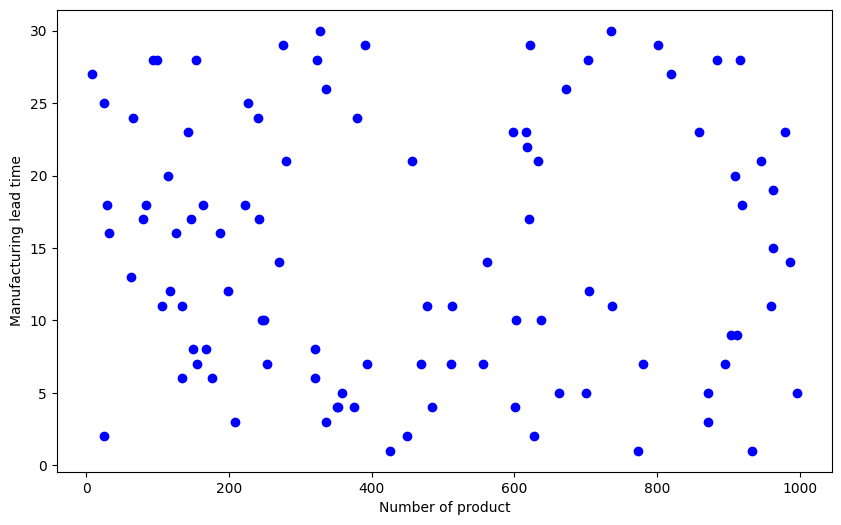

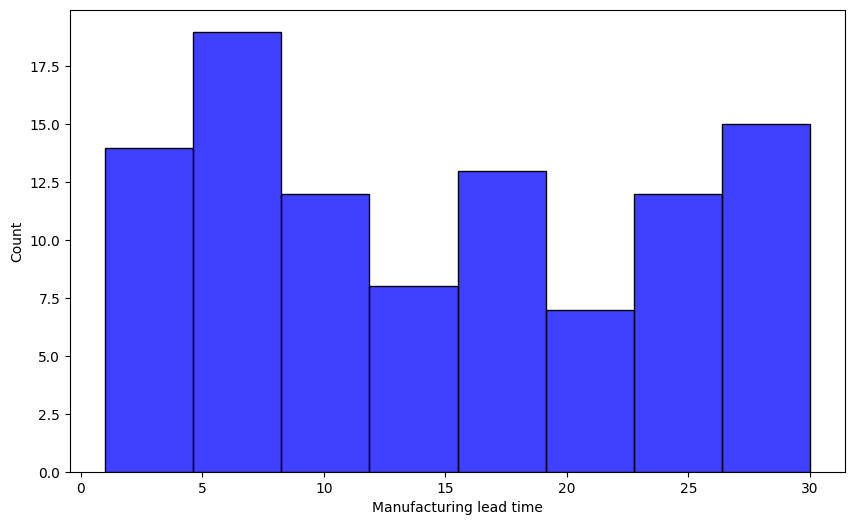

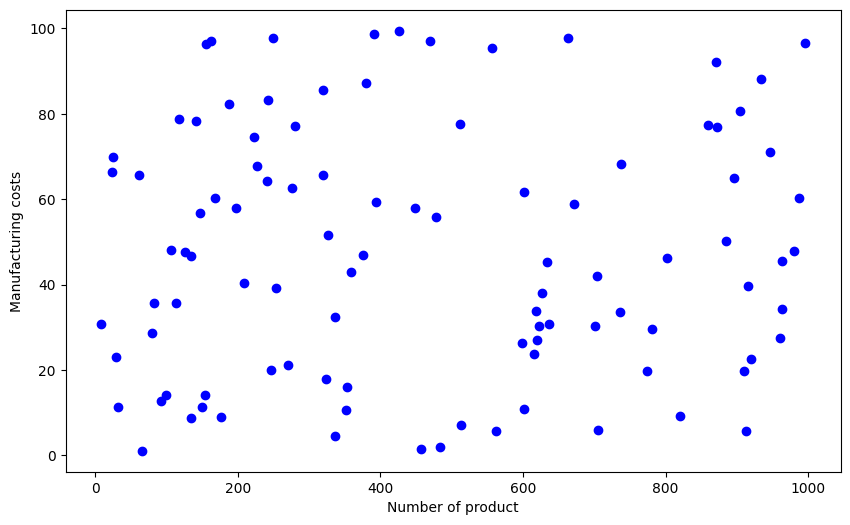

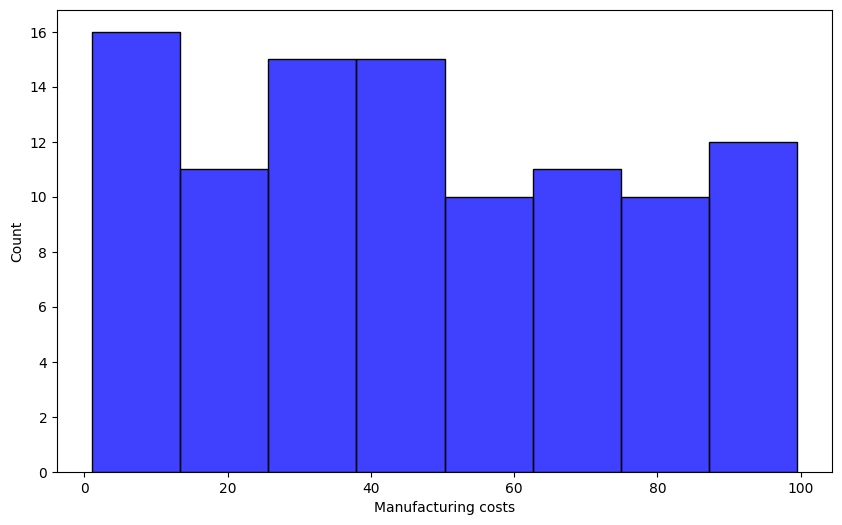

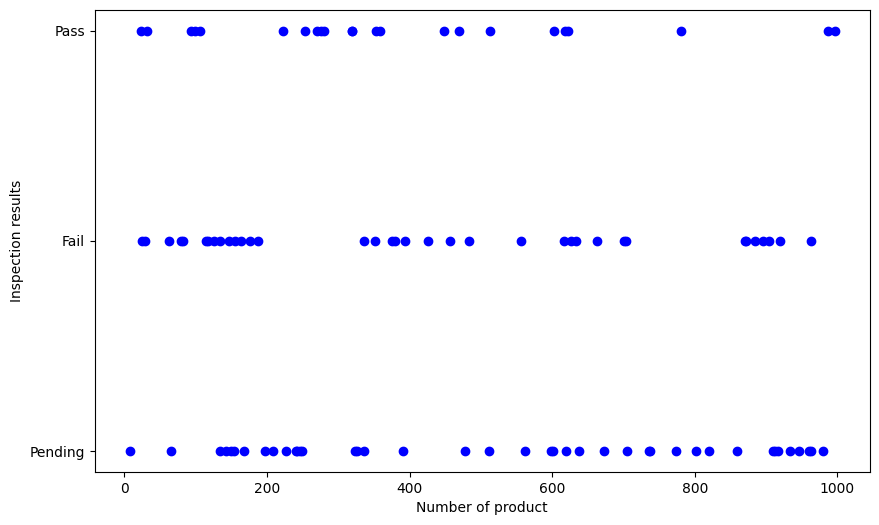

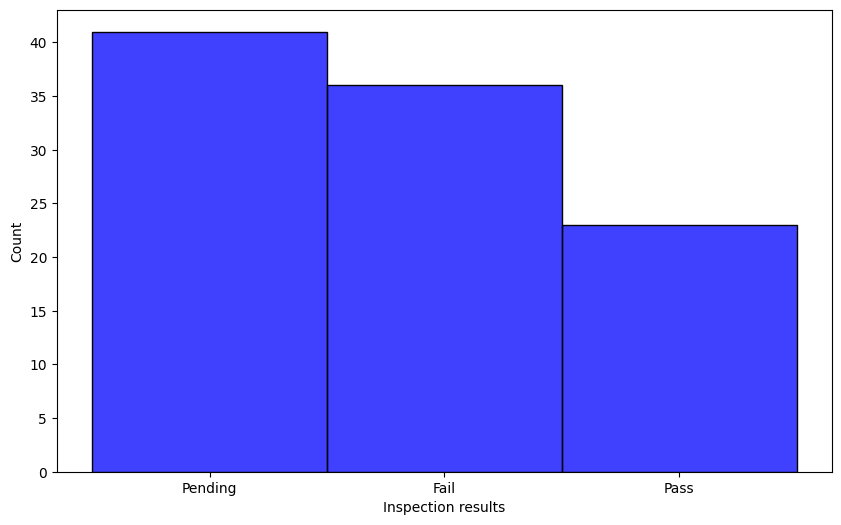

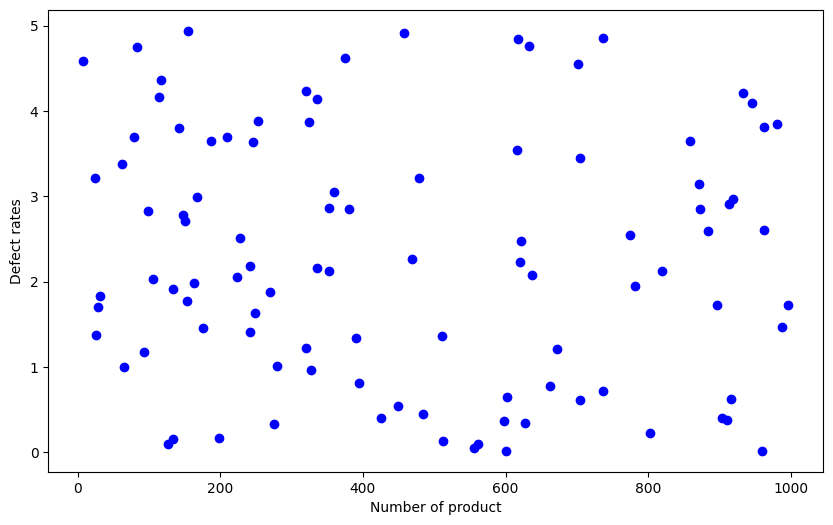

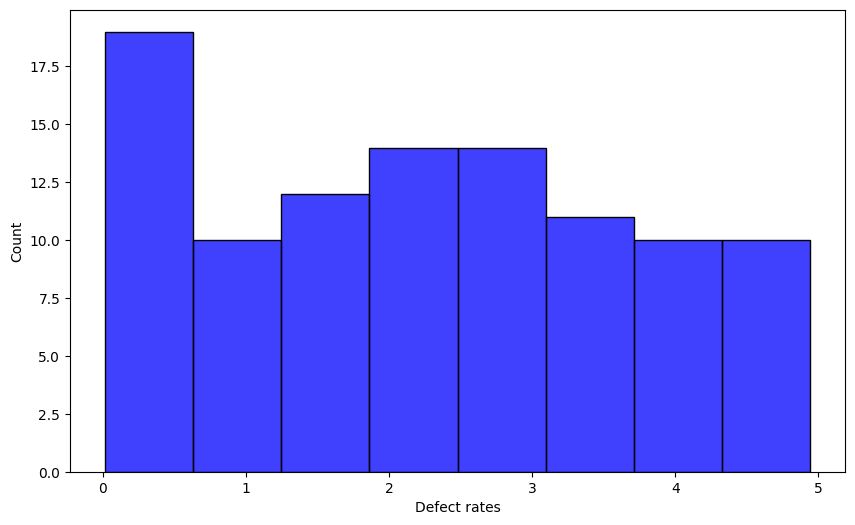

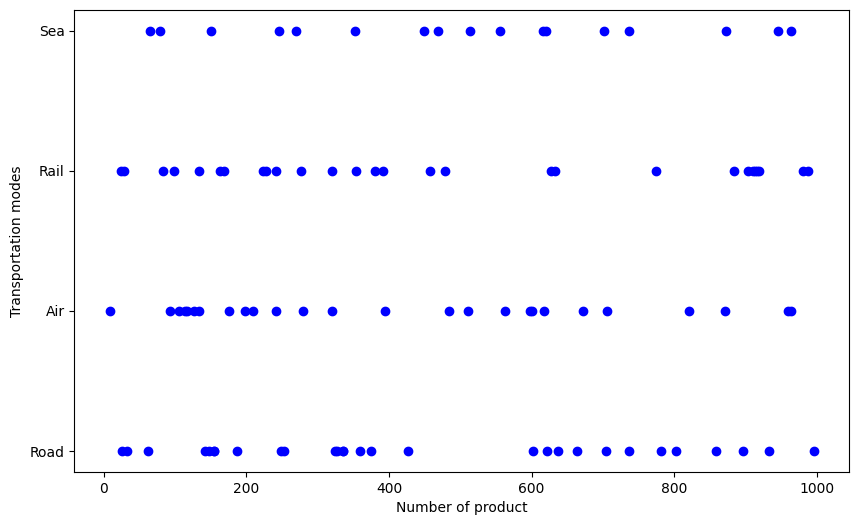

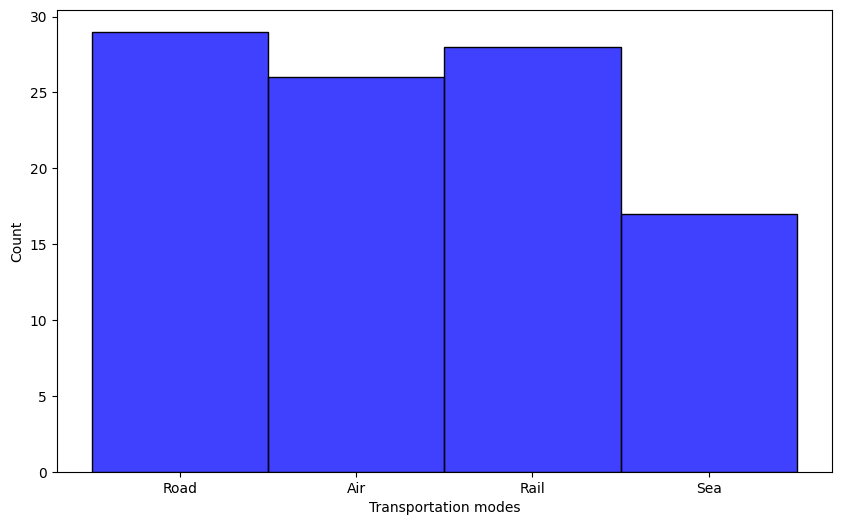

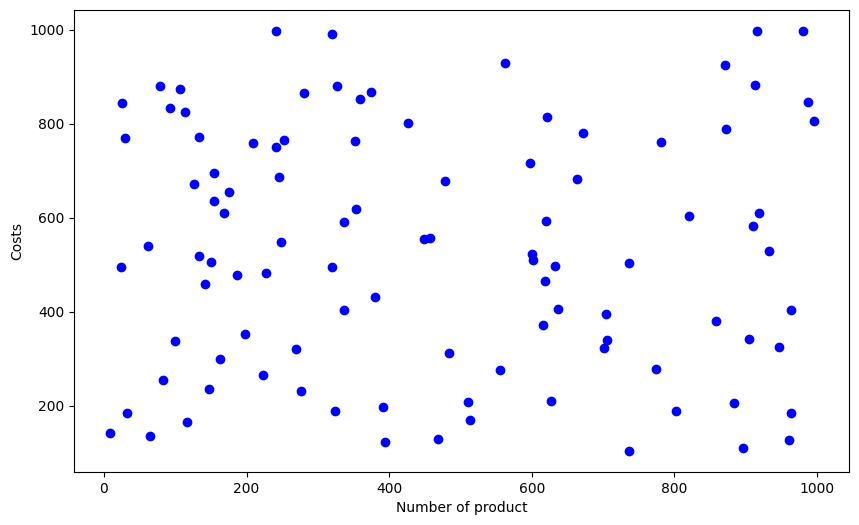

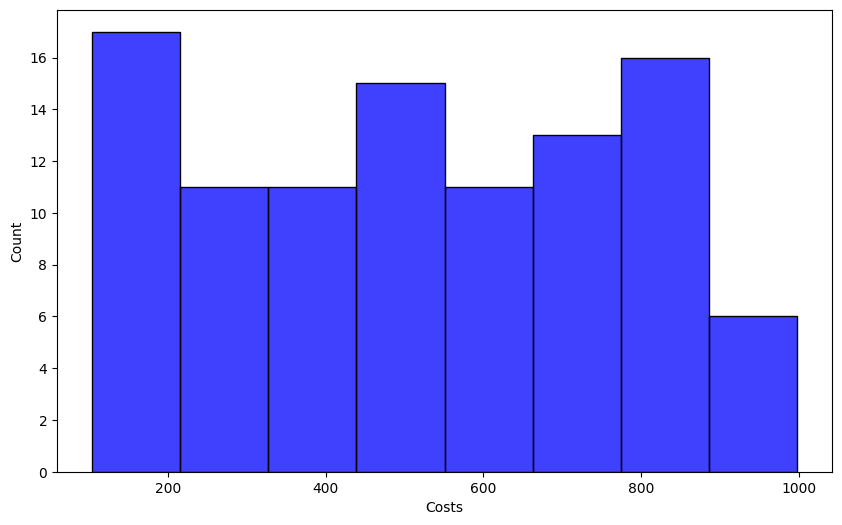

In [57]:

for i in df.columns:
    plt.figure(figsize=(10,6))
    plt.scatter(df['Number of products sold'],df[i],color='blue')
    plt.xlabel('Number of product')
    plt.ylabel(i)
    plt.figure(figsize=(10,6))
    sns.histplot(df[i],color='blue')
    plt.xlabel(i)



In [62]:
df.columns

Index(['Product type', 'Price', 'Availability', 'Number of products sold',
       'Revenue generated', 'Customer demographics', 'Stock levels',
       'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers',
       'Shipping costs', 'Location', 'Lead time', 'Production volumes',
       'Manufacturing lead time', 'Manufacturing costs', 'Inspection results',
       'Defect rates', 'Transportation modes', 'Costs'],
      dtype='object')

In [137]:
X=[
    'Price',
    'Number of products sold',
    'Lead times',
    'Order quantities',
    'Production volumes',
    'Revenue generated',
    'Availability',
    'Lead times',
    'Order quantities',
    'Shipping times',
    'Manufacturing lead time',
    'Manufacturing costs',
    'Defect rates',
    'Costs'


]
y=df['Stock levels']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scale_data=scaler.fit_transform(df[X])
standerd_data=pd.DataFrame(scale_data,columns=X,index=df.index)
standerd_data.describe()


,Price,Number of products sold,Lead times,Order quantities,Production volumes,Revenue generated,Availability,Lead times,Order quantities,Shipping times,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
mean,3.597123e-16,-2.997602e-17,-8.659740e-17,1.443290e-17,-1.221245e-16,1.354472e-16,5.551115e-17,-8.659740e-17,1.443290e-17,-4.718448e-18,5.773160e-17,-1.099121e-16,2.442491e-17,9.103829e-17
std,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00
min,-1.540131e+00,-1.498690e+00,-1.711326e+00,-1.809369e+00,-1.772219e+00,-1.733792e+00,-1.549566e+00,-1.711326e+00,-1.809369e+00,-1.752362e+00,-1.552817e+00,-1.601440e+00,-1.553293e+00,-1.654934e+00
25%,-9.630039e-01,-9.155774e-01,-9.105716e-01,-8.712890e-01,-8.246719e-01,-1.089755e+00,-8.385309e-01,-9.105716e-01,-8.712890e-01,-7.378366e-01,-8.762081e-01,-8.420751e-01,-8.717145e-01,-8.189169e-01
50%,5.731238e-02,-2.265950e-01,1.189692e-01,1.043145e-01,2.521699e-03,8.469721e-02,-1.601872e-01,1.189692e-01,1.043145e-01,9.222958e-02,-8.683144e-02,-4.719787e-02,-9.304784e-02,-3.430000e-02
75%,8.943571e-01,8.048108e-01,9.197231e-01,8.266364e-01,8.755644e-01,9.112903e-01,8.695876e-01,9.197231e-01,8.266364e-01,8.300662e-01,9.280814e-01,7.405041e-01,8.850080e-01,9.098293e-01
max,1.602893e+00,1.770048e+00,1.606084e+00,1.755336e+00,1.593866e+00,1.504304e+00,1.686869e+00,1.606084e+00,1.755336e+00,1.567903e+00,1.717458e+00,1.810119e+00,1.830828e+00,1.821615e+00


In [138]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(standerd_data,y,test_size=0.2,random_state=42)
from sklearn.linear_model import Ridge
model=Ridge(alpha=1.0)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)  
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 1089.7528962869487
R-squared: 0.028013043377440483


In [141]:
#now  check the prediction of the model
new_data = {
    'Price': [1000],
    'Number of products sold': [50],
    'Lead times': [5],
    'Order quantities': [20],
    'Production volumes': [200],
    'Revenue generated': [5000],
    'Availability': [0.8],
    'Shipping times': [3],
    'Manufacturing lead time': [7],
    'Manufacturing costs': [3000],
    'Defect rates': [0.02],
    'Costs': [4000]
}
new_data_df = pd.DataFrame(new_data)
new_data_scaled = scaler.transform(new_data_df[X])
predicted_stock_level = model.predict(new_data_scaled)
print("Predicted Stock required:", predicted_stock_level[0])

Predicted Stock required: 142.94624245960196


c:\Users\RAJARSHEE\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
